In [1]:
#basics of Probability

import random

# a. Tossing a coin 10,000 times
heads = tails = 0
for _ in range(10000):
    if random.choice(['H', 'T']) == 'H':
        heads += 1
    else:
        tails += 1
print("Heads Probability:", heads / 10000)
print("Tails Probability:", tails / 10000)

# b. Rolling two dice and checking for sum = 7
count = 0
for _ in range(10000):
    if random.randint(1, 6) + random.randint(1, 6) == 7:
        count += 1
print("Probability of sum 7:", count / 10000)


Heads Probability: 0.5068
Tails Probability: 0.4932
Probability of sum 7: 0.161


In [2]:
#At least one "6" in 10 rolls

def estimate_one_six(trials=10000):
    success = 0
    for _ in range(trials):
        rolls = [random.randint(1, 6) for _ in range(10)]
        if 6 in rolls:
            success += 1
    return success / trials

print("Estimated Probability:", estimate_one_six())


Estimated Probability: 0.8416


In [3]:
#Conditional Probability & Bayes’ Theorem

colors = ['R'] * 5 + ['G'] * 7 + ['B'] * 8
draws = []

# Simulate 1000 draws with replacement
for _ in range(1000):
    draws.append(random.choice(colors))

# a. P(Red | Previous was Blue)
count_blue = count_red_after_blue = 0
for i in range(1, len(draws)):
    if draws[i - 1] == 'B':
        count_blue += 1
        if draws[i] == 'R':
            count_red_after_blue += 1

if count_blue > 0:
    print("P(Red | Previous Blue):", count_red_after_blue / count_blue)
else:
    print("No blue draws to condition on.")

# b. Bayes’ Theorem verification (empirical)
# P(R) = 5/20, P(B) = 8/20, P(B|R) = ?
count_red = draws.count('R')
count_blue_after_red = 0
for i in range(1, len(draws)):
    if draws[i - 1] == 'R' and draws[i] == 'B':
        count_blue_after_red += 1
if count_red > 0:
    p_b_given_r = count_blue_after_red / count_red
    p_r = 5 / 20
    p_b = 8 / 20
    p_r_given_b = (p_b_given_r * p_r) / p_b
    print("Bayes' Theorem Estimate P(R|B):", p_r_given_b)


P(Red | Previous Blue): 0.22164948453608246
Bayes' Theorem Estimate P(R|B): 0.25297619047619047


In [4]:
#Discrete Random Variable

import numpy as np

values = [1, 2, 3]
probabilities = [0.25, 0.35, 0.4]
sample = np.random.choice(values, size=1000, p=probabilities)

print("Mean:", np.mean(sample))
print("Variance:", np.var(sample))
print("Standard Deviation:", np.std(sample))


Mean: 2.206
Variance: 0.6015640000000001
Standard Deviation: 0.7756055698613826


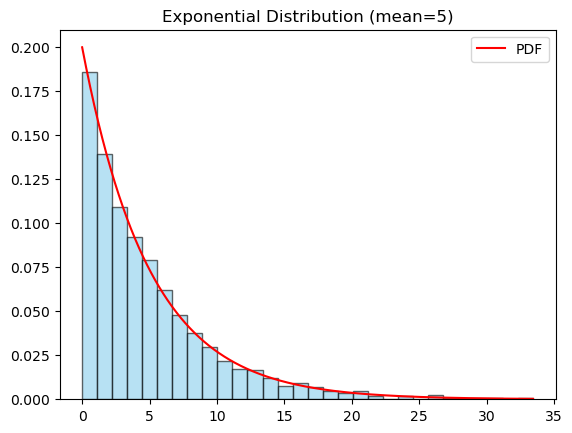

In [5]:
#Exponential Distribution

import matplotlib.pyplot as plt

data = np.random.exponential(scale=5, size=2000)

# a. Histogram
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# b. PDF Overlay
from scipy.stats import expon
x = np.linspace(0, max(data), 1000)
pdf = expon.pdf(x, scale=5)
plt.plot(x, pdf, 'r-', label='PDF')
plt.title("Exponential Distribution (mean=5)")
plt.legend()
plt.show()



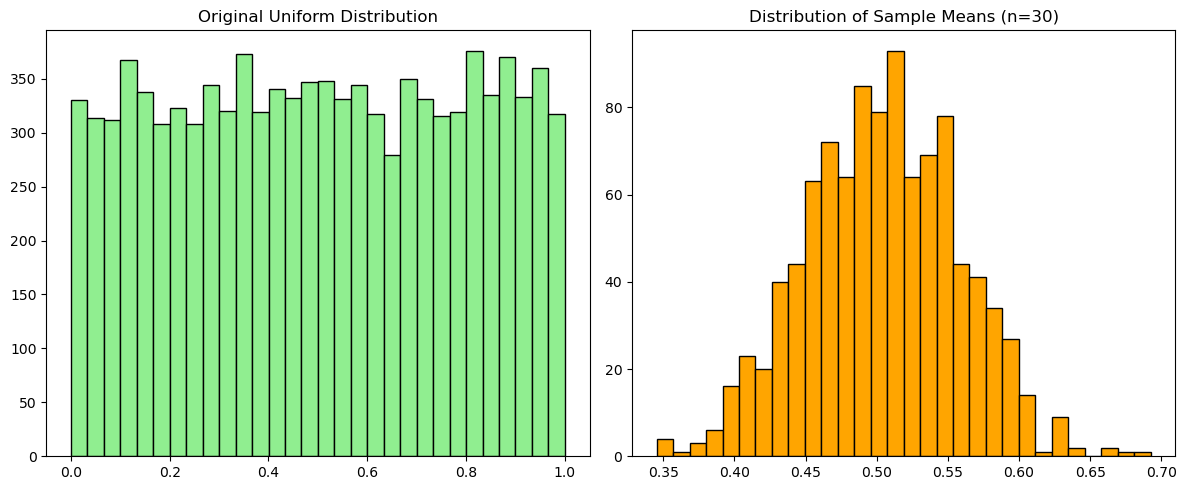

In [6]:
#Central Limit Theorem

# a. Uniform distribution
uniform_data = np.random.uniform(0, 1, 10000)

# b. Sample means
sample_means = []
for _ in range(1000):
    sample = np.random.choice(uniform_data, size=30)
    sample_means.append(np.mean(sample))

# c. Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(uniform_data, bins=30, color='lightgreen', edgecolor='black')
plt.title("Original Uniform Distribution")

plt.subplot(1, 2, 2)
plt.hist(sample_means, bins=30, color='orange', edgecolor='black')
plt.title("Distribution of Sample Means (n=30)")

plt.tight_layout()
plt.show()
